# Decision trees

## Components and structure

A decision tree predicts a target by asking a sequence of simple yes/no questions about the input features, organized as a binary tree. Starting at the root node, each internal node splits the data according to a threshold on a single feature (e.g. "is feature $j$ less than $t$?"); the two branches lead to child nodes, and this repeats until a *leaf* node is reached, which holds the prediction (a class label, by majority vote of the training samples that end up there).

## Choosing the best split

At each node, the tree-building algorithm searches over all features and thresholds for the split that makes the resulting child nodes as "pure" as possible, i.e. each child should ideally contain samples from a single class. Purity (or rather, impurity) is most commonly measured with the Gini index,

$$
G = 1 - \sum_{c=1}^{C} p_c^2
$$

where $p_c$ is the proportion of samples belonging to class $c$ at that node, and $C$ is the number of classes. $G = 0$ for a perfectly pure node (all samples belong to one class), and $G$ is maximal when classes are evenly mixed.

The split chosen at a node is the one that maximizes the weighted decrease in impurity between the parent node and its two children,

$$
\Delta G = G_\mathrm{parent} - \left( \frac{N_\mathrm{left}}{N_\mathrm{parent}} G_\mathrm{left} + \frac{N_\mathrm{right}}{N_\mathrm{parent}} G_\mathrm{right} \right)
$$

where $N$ denotes the number of samples in each node. This greedy, one-split-at-a-time procedure is repeated recursively until a stopping criterion is met (e.g. a maximum depth, or a minimum number of samples per leaf).

## Library imports

In [1]:
import matplotlib.pyplot as plt
import sklearn


## Data preparation

We use the same breast cancer data set as in the basic neural network notebook: 569 samples, 30 features, and a binary target (malignant/benign).

In [2]:
cancer = sklearn.datasets.load_breast_cancer()
X, y = cancer["data"], cancer["target"]

X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=0,
)


No feature scaling is required for decision trees: splits are based on thresholds on individual features, so the algorithm is invariant to monotonic transformations of the data (unlike neural networks or SVMs).

## Model definition

We limit the maximum depth of the tree to keep it both interpretable and resistant to overfitting (an unconstrained tree can grow until every leaf is pure, which usually means memorizing the training data).

In [3]:
tree = sklearn.tree.DecisionTreeClassifier(
    criterion="gini",
    max_depth=3,
    random_state=0,
)


## Model training

In [4]:
tree.fit(X_train, y_train)


,criterion,'gini'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


## Visualizing the tree

The trained tree can be drawn directly, showing the feature, threshold, and Gini impurity, Eq. (1), chosen at every node.

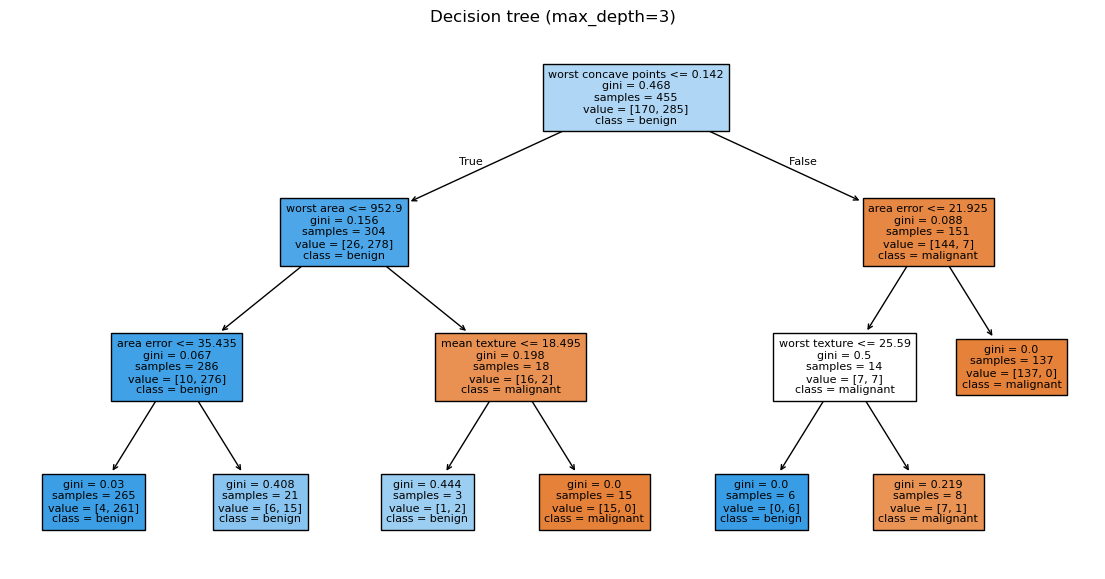

In [5]:
plt.figure(figsize=(14, 7))
sklearn.tree.plot_tree(
    tree,
    feature_names=cancer["feature_names"],
    class_names=cancer["target_names"],
    filled=True,
    fontsize=8,
)
plt.title("Decision tree (max_depth=3)")
plt.show()


## Model evaluation

In [6]:
y_pred = tree.predict(X_test)

print(sklearn.metrics.classification_report(y_test, y_pred, target_names=cancer["target_names"]))


              precision    recall  f1-score   support

   malignant       0.88      0.90      0.89        42
      benign       0.94      0.93      0.94        72

    accuracy                           0.92       114
   macro avg       0.91      0.92      0.92       114
weighted avg       0.92      0.92      0.92       114



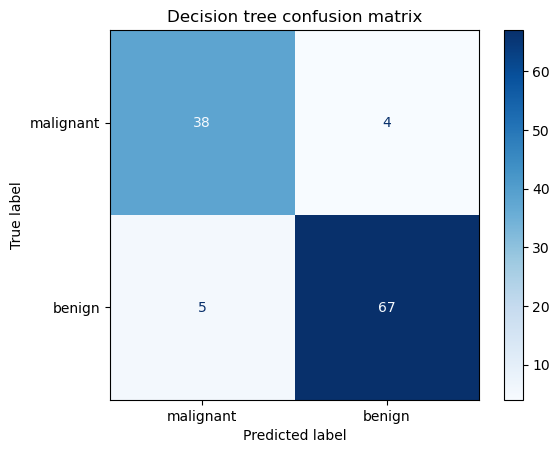

In [7]:
cm = sklearn.metrics.confusion_matrix(y_test, y_pred)
disp = sklearn.metrics.ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=cancer["target_names"])
disp.plot(cmap=plt.cm.Blues)
plt.title("Decision tree confusion matrix")
plt.show()


## Feature importance

A useful by-product of decision trees is a built-in measure of feature importance: how much each feature contributed to reducing impurity (summed Eq. (2) over all nodes where it was used), normalized to sum to 1.

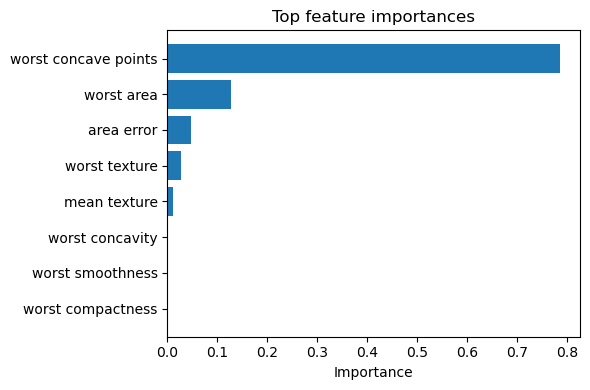

In [8]:
importances = tree.feature_importances_
order = importances.argsort()[::-1][:8]

plt.figure(figsize=(6, 4))
plt.barh(
    [cancer["feature_names"][i] for i in order][::-1],
    importances[order][::-1],
)
plt.xlabel("Importance")
plt.title("Top feature importances")
plt.tight_layout()
plt.show()


## Take-away

A single decision tree is fast to train, requires no feature scaling, and is highly interpretable — the diagram above can literally be read out loud as a sequence of decision rules. Its main weakness is high variance: small changes in the training data can lead to a very different tree. This motivates *ensembles* of trees (random forests, gradient boosting), covered in the next notebooks, which trade some interpretability for substantially better and more stable predictive performance.